# LangGraph Basics: Conditional Email Routing

This notebook introduces LangGraph with a small deterministic workflow. The graph reads an incoming email, classifies it, and then chooses one of three paths:

- draft a normal reply
- escalate an urgent or account-related email
- end immediately when no action is needed

The goal is to understand state, nodes, edges, and conditional routing before adding LLM calls or tools.

## Environment setup

LangGraph is already listed in this repository's dependencies. This example only uses Python functions, so it does not require an API key.

In [1]:
from pprint import pprint
from typing import Literal, TypedDict

from IPython.display import Image, Markdown, display
from langgraph.graph import END, START, StateGraph

## Define the graph state

LangGraph passes a shared state dictionary through the workflow. Each node receives the current state and returns only the fields it wants to add or update.

In [2]:
class EmailState(TypedDict, total=False):
    email: str
    category: Literal["question", "billing", "account", "fyi"]
    priority: Literal["normal", "urgent"]
    next_step: Literal["reply", "escalate", "ignore"]
    draft_response: str
    escalation_note: str

## Define nodes

Nodes are regular Python functions. The first node classifies the email and decides which high-level route the graph should take next.

In [3]:
def classify_email(state: EmailState) -> EmailState:
    email = state["email"].lower()

    urgent_terms = ["urgent", "asap", "immediately", "broken", "locked out"]
    billing_terms = ["bill", "billing", "invoice", "refund", "charge"]
    account_terms = ["account", "password", "login", "locked out"]
    fyi_terms = ["fyi", "for your information", "no action needed"]

    priority = "urgent" if any(term in email for term in urgent_terms) else "normal"

    if any(term in email for term in billing_terms):
        category = "billing"
    elif any(term in email for term in account_terms):
        category = "account"
    elif any(term in email for term in fyi_terms):
        category = "fyi"
    else:
        category = "question"

    if category == "fyi":
        next_step = "ignore"
    elif priority == "urgent" or category in {"billing", "account"}:
        next_step = "escalate"
    else:
        next_step = "reply"

    return {
        "category": category,
        "priority": priority,
        "next_step": next_step,
    }


def draft_reply(state: EmailState) -> EmailState:
    return {
        "draft_response": (
            "Thanks for reaching out. Here is a short answer to your question. "
            "If you need more detail, reply with a specific example."
        )
    }


def escalate(state: EmailState) -> EmailState:
    return {
        "escalation_note": (
            f"Escalate this {state['priority']} {state['category']} email "
            "to the support lead. Include the original email and customer history."
        )
    }

## Define the conditional route

A router is also a regular function. It reads the current state and returns a label. LangGraph maps that label to the next node or to `END`.

In general, `add_conditional_edges` connects one source node to multiple possible destinations. It takes three important pieces:

- the source node name, such as `"classify_email"`
- a routing function, such as `route_email`, that receives the latest graph state
- a mapping from router return values to destination nodes or `END`

At runtime, LangGraph first runs the source node and merges that node's returned updates into the state. Then it calls the router with the updated state. The value returned by the router is looked up in the mapping, and that mapped destination becomes the next step.

In [4]:
def route_email(state: EmailState) -> Literal["reply", "escalate", "ignore"]:
    return state["next_step"]

## Build the graph

The workflow starts at `classify_email`. After classification, the conditional edge chooses whether to reply, escalate, or finish immediately.

In [5]:
builder = StateGraph(EmailState)

builder.add_node("classify_email", classify_email)
builder.add_node("draft_reply", draft_reply)
builder.add_node("escalate", escalate)

builder.add_edge(START, "classify_email")
builder.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "reply": "draft_reply",
        "escalate": "escalate",
        "ignore": END,
    },
)
builder.add_edge("draft_reply", END)
builder.add_edge("escalate", END)

graph = builder.compile()

## Inspect the graph

The image shows the start node, classification node, conditional routes, and finish node. The next cell also prints the Mermaid source so the graph structure is visible even when image rendering is unavailable.

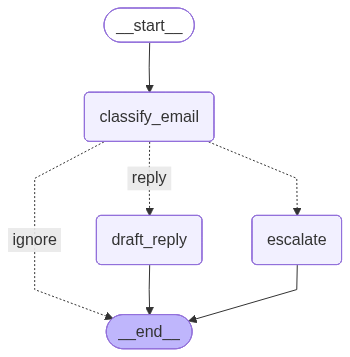

In [6]:
try:
    display(Image(graph.get_graph().draw_mermaid_png(max_retries=1, retry_delay=0.2)))
except Exception as exc:
    display(
        Markdown(
            "Graph image rendering is unavailable in this environment. "
            f"The Mermaid source is printed below. Renderer error: `{type(exc).__name__}`."
        )
    )

In [7]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify_email(classify_email)
	draft_reply(draft_reply)
	escalate(escalate)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify_email;
	classify_email -. &nbsp;ignore&nbsp; .-> __end__;
	classify_email -. &nbsp;reply&nbsp; .-> draft_reply;
	classify_email -.-> escalate;
	draft_reply --> __end__;
	escalate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Invoke the graph

Each input starts with only an `email` field. The graph fills in the classification fields and then adds either a reply, an escalation note, or nothing else.

In [8]:
sample_emails = [
    "Can you explain how to reset my workspace settings?",
    "URGENT: I am locked out of my account and need access immediately.",
    "FYI, the weekly report was uploaded. No action needed.",
]

for email in sample_emails:
    print("=" * 80)
    print(email)
    pprint(graph.invoke({"email": email}))

Can you explain how to reset my workspace settings?
{'category': 'question',
 'draft_response': 'Thanks for reaching out. Here is a short answer to your '
                   'question. If you need more detail, reply with a specific '
                   'example.',
 'email': 'Can you explain how to reset my workspace settings?',
 'next_step': 'reply',
 'priority': 'normal'}
URGENT: I am locked out of my account and need access immediately.
{'category': 'account',
 'email': 'URGENT: I am locked out of my account and need access immediately.',
 'escalation_note': 'Escalate this urgent account email to the support lead. '
                    'Include the original email and customer history.',
 'next_step': 'escalate',
 'priority': 'urgent'}
FYI, the weekly report was uploaded. No action needed.
{'category': 'fyi',
 'email': 'FYI, the weekly report was uploaded. No action needed.',
 'next_step': 'ignore',
 'priority': 'normal'}


## Stream intermediate steps

`stream` is useful while developing because it shows which nodes ran and what each node returned.

In [9]:
for update in graph.stream(
    {"email": "Please refund the duplicate charge on my latest invoice."}
):
    pprint(update)

{'classify_email': {'category': 'billing',
                    'next_step': 'escalate',
                    'priority': 'normal'}}
{'escalate': {'escalation_note': 'Escalate this normal billing email to the '
                                 'support lead. Include the original email and '
                                 'customer history.'}}


## Key takeaways

- State is the shared memory for a graph run.
- Nodes are functions that return state updates.
- Conditional edges route by returning labels from a router function.
- The same pattern can later use LLM calls, tools, or human review inside individual nodes.